<a href="https://colab.research.google.com/github/Em-Esh-Magar/AI-ML_Algorithm/blob/main/Logistic_Regression/Credit_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data = pd.read_csv('/content/credit_risk_dataset.csv')

In [4]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
data.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [8]:
data['cb_person_default_on_file'].unique()

array(['Y', 'N'], dtype=object)

In [9]:
data[data['cb_person_default_on_file']=='Y']

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
21,25,137000,RENT,9.0,PERSONAL,E,34800,16.77,0,0.25,Y,2
24,22,80000,RENT,3.0,PERSONAL,D,33950,14.54,1,0.42,Y,4
26,21,11000,MORTGAGE,3.0,VENTURE,E,4575,17.74,1,0.42,Y,3
...,...,...,...,...,...,...,...,...,...,...,...,...
32552,65,45900,RENT,2.0,EDUCATION,C,10000,NaN,0,0.22,Y,19
32555,51,80000,RENT,3.0,HOMEIMPROVEMENT,F,18000,18.78,0,0.23,Y,20
32563,52,71520,RENT,0.0,EDUCATION,E,7000,16.82,1,0.10,Y,24
32568,60,49008,OWN,5.0,PERSONAL,C,12000,13.79,0,0.24,Y,21


In [10]:
data[data['person_emp_length']==0]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
16,23,120000,RENT,0.0,EDUCATION,A,35000,7.90,0,0.29,N,4
23,24,10980,OWN,0.0,PERSONAL,A,1500,7.29,0,0.14,N,3
27,23,11000,OWN,0.0,PERSONAL,A,1400,9.32,0,0.13,N,3
45,26,300000,MORTGAGE,0.0,EDUCATION,D,25000,15.33,0,0.08,N,3
49,26,89028,RENT,0.0,DEBTCONSOLIDATION,A,30000,6.62,1,0.34,N,3
...,...,...,...,...,...,...,...,...,...,...,...,...
32563,52,71520,RENT,0.0,EDUCATION,E,7000,16.82,1,0.10,Y,24
32564,53,45000,RENT,0.0,PERSONAL,C,5600,13.79,0,0.12,N,28
32572,52,52000,OWN,0.0,PERSONAL,A,9600,8.49,0,0.18,N,22
32573,56,90000,MORTGAGE,0.0,PERSONAL,A,7200,6.17,0,0.08,N,19


In [11]:
data['person_emp_length'] = data['person_emp_length'].apply(lambda x:x if x>=0 else 1)

In [12]:
data['person_emp_length'].isna().sum()

np.int64(0)

In [13]:
data['loan_int_rate'].isna().sum()

np.int64(3116)

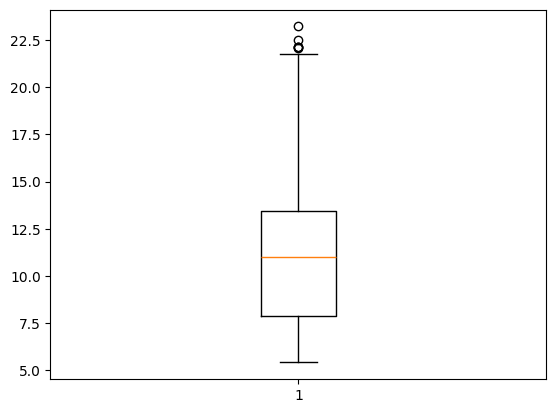

In [14]:
plt.boxplot(data['loan_int_rate'].dropna())
plt.show()

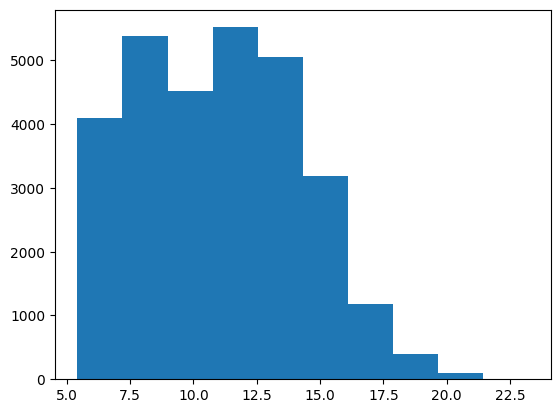

In [15]:
plt.hist(data['loan_int_rate'].dropna())
plt.show()

In [16]:
data['loan_int_rate'] = data['loan_int_rate'].fillna(data['loan_int_rate'].median())

In [17]:
data.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


#### Feature Enginerring

In [18]:
data['loan_int_rate'].unique()

array([16.02, 11.14, 12.87, 15.23, 14.27,  7.14, 12.42, 11.11,  8.9 ,
       14.74, 10.37,  8.63,  7.9 , 18.39, 10.65, 20.25, 18.25, 10.99,
        7.49, 16.77, 17.58,  7.29, 14.54, 12.68, 17.74,  9.32,  9.99,
       12.84, 11.12,  6.62, 14.17, 13.85, 13.49,  7.51, 16.89, 17.99,
       12.69,  7.88, 19.41, 10.38, 15.33, 16.45, 18.62, 15.96, 11.48,
        5.99, 11.58, 15.7 , 15.99, 14.84, 14.42,  6.99, 13.61,  9.91,
       13.48, 12.98, 13.57, 15.68, 13.06, 15.62, 11.71,  8.88, 12.18,
       13.99,  5.42, 12.73, 11.49, 19.91, 11.83, 14.59,  9.64, 16.35,
       18.67, 10.08, 10.36, 12.23, 16.07, 14.22, 14.79, 13.22, 11.86,
       13.43, 15.28, 17.93,  9.25, 10.62, 18.43, 11.36, 15.65, 13.04,
       17.04, 14.83, 14.65, 16.82, 10.25, 14.96, 11.99,  8.49,  6.17,
       16.32, 14.35, 15.21, 14.09, 17.49, 13.92, 16.49,  5.79, 13.11,
        6.54, 12.53, 15.95, 10.74, 15.27, 14.72, 13.35,  7.68, 14.46,
       13.47,  6.03, 12.92, 18.64, 16.7 , 18.3 ,  9.63, 14.7 , 15.37,
       14.26,  8.  ,

In [19]:
data['Int_Amount'] = (data['loan_int_rate'] * data['loan_amnt'] * 1) / 100

In [20]:
data['Int_Amount']

,Int_Amount
0,5607.0000
1,111.4000
2,707.8500
3,5330.5000
4,4994.5000
...,...
32576,763.2800
32577,1320.1125
32578,3846.5000
32579,1722.0000


In [21]:
data['Total_with_Int_per_year'] = data['Int_Amount'] + data['loan_amnt']

In [ ]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Int_Amount,Total_with_Int_per_year
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,5607.00,40607.00
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,111.40,1111.40
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,707.85,6207.85
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,5330.50,40330.50
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,4994.50,39994.50


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
 12  Int_Amount                  32581 non-null  float64
 13  Total_with_Int_per_year     325

### Converting into integer

#### for person home ownership

In [23]:
data['person_home_ownership'].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

In [25]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [26]:
encoded_data = data

In [27]:
order = ['OWN', 'RENT', 'MORTGAGE', 'OTHER']
my_encoder_ownership = OrdinalEncoder(categories=[order],dtype=int)
encoded_data['person_home_ownership'] = my_encoder_ownership.fit_transform(data[['person_home_ownership']])

In [28]:
encoded_data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Int_Amount,Total_with_Int_per_year
0,22,59000,1,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,5607.00,40607.00
1,21,9600,0,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,111.40,1111.40
2,25,9600,2,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,707.85,6207.85
3,23,65500,1,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,5330.50,40330.50
4,24,54400,1,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,4994.50,39994.50


#### For the loan_intent

In [29]:
encoded_data['loan_intent'].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [30]:
encoded_data= pd.get_dummies(encoded_data, columns=['loan_intent'], dtype=int)

In [31]:
encoded_data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Int_Amount,Total_with_Int_per_year,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,59000,1,123.0,D,35000,16.02,1,0.59,Y,3,5607.00,40607.00,0,0,0,0,1,0
1,21,9600,0,5.0,B,1000,11.14,0,0.10,N,2,111.40,1111.40,0,1,0,0,0,0
2,25,9600,2,1.0,C,5500,12.87,1,0.57,N,3,707.85,6207.85,0,0,0,1,0,0
3,23,65500,1,4.0,C,35000,15.23,1,0.53,N,2,5330.50,40330.50,0,0,0,1,0,0
4,24,54400,1,8.0,C,35000,14.27,1,0.55,Y,4,4994.50,39994.50,0,0,0,1,0,0


#### For loan grade

In [32]:
encoded_data['loan_grade'].unique()

array(['D', 'B', 'C', 'A', 'E', 'F', 'G'], dtype=object)

In [33]:
order_grade = ['A','B','C','D','E','F','G']
order_encoder = OrdinalEncoder(categories=[order_grade],dtype=int)
encoded_data['loan_grade'] = order_encoder.fit_transform(encoded_data[['loan_grade']])

In [34]:
encoded_data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Int_Amount,Total_with_Int_per_year,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,59000,1,123.0,3,35000,16.02,1,0.59,Y,3,5607.00,40607.00,0,0,0,0,1,0
1,21,9600,0,5.0,1,1000,11.14,0,0.10,N,2,111.40,1111.40,0,1,0,0,0,0
2,25,9600,2,1.0,2,5500,12.87,1,0.57,N,3,707.85,6207.85,0,0,0,1,0,0
3,23,65500,1,4.0,2,35000,15.23,1,0.53,N,2,5330.50,40330.50,0,0,0,1,0,0
4,24,54400,1,8.0,2,35000,14.27,1,0.55,Y,4,4994.50,39994.50,0,0,0,1,0,0


### For cb_person_default_on_file

In [35]:
encoded_data['cb_person_default_on_file'] = encoded_data['cb_person_default_on_file'].apply(lambda x:1 if x=='Y' else 0)

In [36]:
encoded_data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Int_Amount,Total_with_Int_per_year,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,59000,1,123.0,3,35000,16.02,1,0.59,1,3,5607.00,40607.00,0,0,0,0,1,0
1,21,9600,0,5.0,1,1000,11.14,0,0.10,0,2,111.40,1111.40,0,1,0,0,0,0
2,25,9600,2,1.0,2,5500,12.87,1,0.57,0,3,707.85,6207.85,0,0,0,1,0,0
3,23,65500,1,4.0,2,35000,15.23,1,0.53,0,2,5330.50,40330.50,0,0,0,1,0,0
4,24,54400,1,8.0,2,35000,14.27,1,0.55,1,4,4994.50,39994.50,0,0,0,1,0,0


In [37]:
encoded_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   person_age                     32581 non-null  int64  
 1   person_income                  32581 non-null  int64  
 2   person_home_ownership          32581 non-null  int64  
 3   person_emp_length              32581 non-null  float64
 4   loan_grade                     32581 non-null  int64  
 5   loan_amnt                      32581 non-null  int64  
 6   loan_int_rate                  32581 non-null  float64
 7   loan_status                    32581 non-null  int64  
 8   loan_percent_income            32581 non-null  float64
 9   cb_person_default_on_file      32581 non-null  int64  
 10  cb_person_cred_hist_length     32581 non-null  int64  
 11  Int_Amount                     32581 non-null  float64
 12  Total_with_Int_per_year        32581 non-null 

### Let's train our model

In [38]:
model = LogisticRegression()
target = encoded_data['loan_status']
train_data = encoded_data.drop(columns=['loan_status'])
model.fit(train_data,target)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [39]:
test_data = encoded_data.drop(columns=['loan_status'])

In [40]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   person_age                     32581 non-null  int64  
 1   person_income                  32581 non-null  int64  
 2   person_home_ownership          32581 non-null  int64  
 3   person_emp_length              32581 non-null  float64
 4   loan_grade                     32581 non-null  int64  
 5   loan_amnt                      32581 non-null  int64  
 6   loan_int_rate                  32581 non-null  float64
 7   loan_percent_income            32581 non-null  float64
 8   cb_person_default_on_file      32581 non-null  int64  
 9   cb_person_cred_hist_length     32581 non-null  int64  
 10  Int_Amount                     32581 non-null  float64
 11  Total_with_Int_per_year        32581 non-null  float64
 12  loan_intent_DEBTCONSOLIDATION  32581 non-null 

In [41]:
test_data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Int_Amount,Total_with_Int_per_year,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,59000,1,123.0,3,35000,16.02,0.59,1,3,5607.00,40607.00,0,0,0,0,1,0
1,21,9600,0,5.0,1,1000,11.14,0.10,0,2,111.40,1111.40,0,1,0,0,0,0
2,25,9600,2,1.0,2,5500,12.87,0.57,0,3,707.85,6207.85,0,0,0,1,0,0
3,23,65500,1,4.0,2,35000,15.23,0.53,0,2,5330.50,40330.50,0,0,0,1,0,0
4,24,54400,1,8.0,2,35000,14.27,0.55,1,4,4994.50,39994.50,0,0,0,1,0,0


In [42]:
test_data.to_csv('/content/credit_risk_cleandata.csv',index=False)

In [44]:
xyz = pd.read_csv('/content/credit_risk_cleandata.csv')
result = model.predict(xyz)
result

array([0, 0, 1, ..., 0, 0, 0])